In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_images(titles, images, is_gray=False):
   """Hàm hỗ trợ hiển thị nhiều ảnh cùng lúc để dễ so sánh"""
   plt.figure(figsize=(15, 5))
   for i in range(len(images)):
      plt.subplot(1, len(images), i+1)
      if is_gray or len(images[i].shape) == 2:
         plt.imshow(images[i],cmap='gray')
      else:
         plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
      plt.title(titles[i])
      plt.axis('off')
   plt.show()

# Đọc ảnh gốc
img = cv2.imread('lab02.jpg')

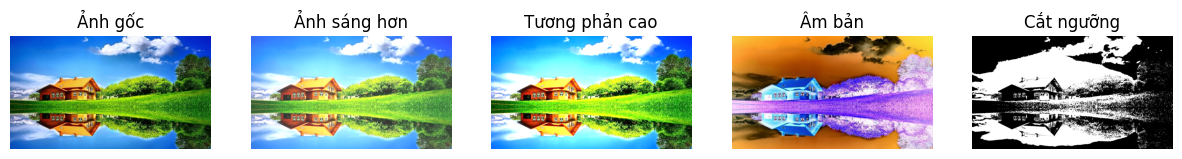

In [ ]:
# Phần 1 - Toán Tử Điểm Ảnh
# 1. Thay đổi độ sáng (Tăng độ sáng lên 50)
matrix_50 = np.ones(img.shape, dtype="uint8") * 50
img_bright = cv2.add(img, matrix_50) # Dùng cv2.add để tránh tràn số (>255

# 2. Thay đổi độ tương phản (Tăng độ tương phản)
# Công thức: g(x) = alpha * f(x) + beta. (alpha > 1 là tăng tương phản)
img_contrast = cv2.convertScaleAbs(img, alpha=1.5, beta=0)

# 3. Biến đổi âm bản (Negative)
# Đảo ngược giá trị: 255 - pixel
img_negative = cv2.bitwise_not(img)

# 4. Cắt ngưỡng (Thresholding) - Thường áp dụng trên ảnh xám
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Nếu pixel > 127 thì biến thành 255 (trắng), ngược lại thành 0 (đen)
_, img_thresh = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

# Hiển thị kết quả
show_images(['Ảnh gốc', 'Ảnh sáng hơn', 'Tương phản cao', 'Âm bản', 'Cắt ngưỡng'],
            [img, img_bright, img_contrast, img_negative, img_thresh])

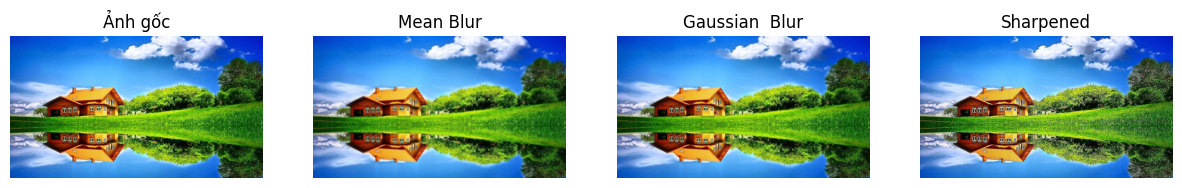

In [6]:
# Phần 2 - Lọc Tuyến Tính (Làm mờ & Làm sắc nét)
# 1. Lọc trung bình (Mean Filter): Lấy trung bình cộng các pixel xung quanh
# Kernel 5x5: kích thước vùng lân cận càng lớn, ảnh càng mờ
img_mean_blur = cv2.blur(img, (5, 5))

# 2. Lọc Gaussian: Làm mờ tự nhiên hơn, giữ lại được các đường nét tốt hơn Mean
# Số 0 ở cuối là độ lệch chuẩn sigmaX, để 0 OpenCV sẽ tự tính toán dựa trên kernel size
img_gaussian_blur = cv2.GaussianBlur(img, (5, 5), 0)

# 3. Làm sắc nét (Sharpening): Sử dụng Custom Kernel
# Tạo một ma trận kernel để tăng cường sự chênh lệch giữa điểm ảnh và xung quanh
sharpen_kernel = np.array([
    [ 0, -1, 0],
    [-1, 5, -1],
    [ 0, -1, 0]
])
# Dùng filter2D để áp kernel vào ảnh
img_sharpen = cv2.filter2D(img, -1, sharpen_kernel)

# Hiển thị kết quả
show_images(['Ảnh gốc', 'Mean Blur', 'Gaussian  Blur', 'Sharpened'],
            [img, img_mean_blur, img_gaussian_blur, img_sharpen])

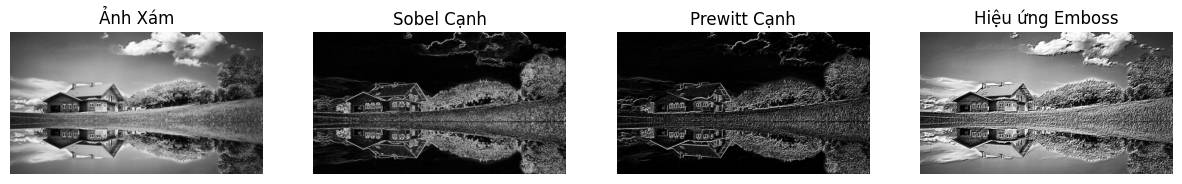

In [4]:
# Phần 3: Bài Tập Nâng Cao
# Chuyển ảnh sang Grayscale trước khi tìm cạnh để dễ xử lý và tính toán nhanh hơn
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ==========================================
# 1.1 Phát hiện cạnh bằng Sobel
# ==========================================
# Tính đạo hàm theo hướng X và Y (dùng CV_64F để giữ giá trị âm khi tính toán)
sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)

# Chuyển về lại uint8 (0-255) bằng trị tuyệt đối
abs_sobel_x = cv2.convertScaleAbs(sobel_x)
abs_sobel_y = cv2.convertScaleAbs(sobel_y)

# Gộp cạnh X và Y lại (trọng số 50-50)
sobel_combined = cv2.addWeighted(abs_sobel_x, 0.5, abs_sobel_y, 0.5, 0)

# ==========================================
# 1.2 Phát hiện cạnh bằng Prewitt (Tự định nghĩa Kernel)
# ==========================================
kernel_prewitt_x = np.array([[-1, 0, 1],
                             [-1, 0, 1],
                             [-1, 0, 1]])
kernel_prewitt_y = np.array([[-1, -1, -1],
                             [0, 0, 0],
                             [1, 1, 1]])

# Dùng filter2D để quét kernel lên ảnh
prewitt_x = cv2.filter2D(img_gray, -1, kernel_prewitt_x)
prewitt_y = cv2.filter2D(img_gray, -1, kernel_prewitt_y)
prewitt_combined = cv2.bitwise_or(prewitt_x, prewitt_y)

# ==========================================
# 2. Tự thiết kế Kernel: Hiệu ứng chạm nổi (Emboss)
# ==========================================
kernel_emboss = np.array([[-2, -1, 0 ],
                          [-1, 1, 1],
                          [0, 1, 2]])
img_emboss = cv2.filter2D(img_gray, -1, kernel_emboss)

# Hiển thị
show_images(['Ảnh Xám', 'Sobel Cạnh', 'Prewitt Cạnh', 'Hiệu ứng Emboss'],
            [img_gray, sobel_combined, prewitt_combined, img_emboss], is_gray=True)

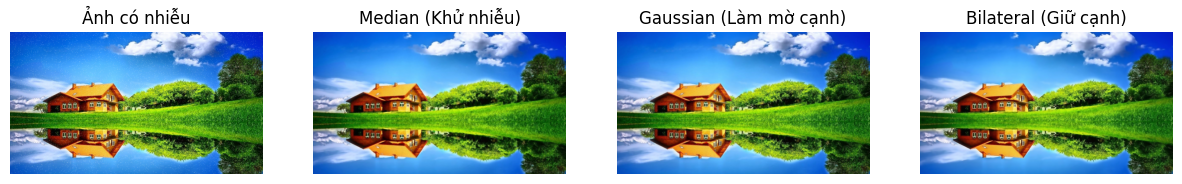

True

In [9]:
# 4.  Lọc Phi Tuyến Tính (Non-linear Filters)
import random
# Tạo một chút nhiễu muối tiêu (Salt & Pepper noise) để test Median Filter
noise_img = img.copy()
# Tạo ngẫu nhiên các chấm trắng (255) và đen (0)
row, col, _ = noise_img.shape
number_of_pixels = random.randint(300, 10000) # Cần import random ở đầu file
for i in range(number_of_pixels):
    y_coord = random.randint(0, row - 1)
    x_coord = random.randint(0, col - 1)
    noise_img[y_coord][x_coord] = 255

# 4.1. Median Filter: Khử nhiễu cực mạnh
# Tham số 5 là kích thước kernel (phải là số lẻ)
img_median = cv2.medianBlur(noise_img, 5)

# 4.2. Bilateral Filter: Làm mịn nhưng giữ cạnh
# Các tham số: (ảnh, kích_thước_lân_cận, sigma_màu, sigma_không_gian)
# Tham số càng lớn thì hiệu ứng làm mịn càng mạnh
img_bilateral = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

# 3. So sánh
show_images(['Ảnh có nhiễu', 'Median (Khử nhiễu)', 'Gaussian (Làm mờ cạnh)', 'Bilateral (Giữ cạnh)'],
            [noise_img, img_median, img_gaussian_blur, img_bilateral])

# Lưu ảnh kết quả
# cv2.imwrite('noise_img.jpg', noise_img)
# cv2.imwrite('img_median.jpg', img_median)
# cv2.imwrite('img_gaussian_blur.jpg', img_gaussian_blur)
# cv2.imwrite('img_bilateral.jpg', img_bilateral)
cv2.imwrite('img_mean_blur.jpg', img_mean_blur)
